In [1]:
import numpy as np
from numpy import pi, arccos, cos, sin, tan, mean
import matplotlib.pyplot as plt
from cats.cdataframe import CDataFrame
import glob
import pandas as pd
from matplotlib.lines import Line2D

Welcome to JupyROOT 6.28/10


In [2]:
h     = 4.13566e-12 # MeV*ns
hbar  = h / (2 * np.pi) # MeV*ns
mass = {'h': 0.50 * 0.51099906 / (2.99792458 * 1e2)**2,
        'e': 1.4672e-6} # MeV ns^2 / mm^2
vsound = 0.009 # mm/ns # Longitudinal sound speed

ksound = {'h': mass['h'] * vsound / hbar,
          'e': mass['e'] * vsound / hbar}

lss = {'G4CMPLukeScattering': '-',
       'CoupledTransportation': '--',
       'G4CMPTimeStepper': 'dotted'}

In [3]:
#colors = {'0V': {'h': '#4376B6',
#                 'e': '#D72B22'},
#          '4V': {'h': '#92C0DC',
#                   'e': '#FC8D57'}}

colors = {'4V': {'h': '#D72B22',
                 'e': '#FC8D57'},
          '0V': {'h': '#3D6CA5',
                   'e': '#92C0DC'}}

label = {'0V': {'h': r'$\mathbf{holes}$ at $\mathbf{0V}$',
                 'e': r'$\mathbf{electrons}$ at $\mathbf{0V}$'},
          '4V': {'h': r'$\mathbf{holes}$ at $\mathbf{4V}$',
                   'e': r'$\mathbf{electrons}$ at $\mathbf{4V}$'}}

In [13]:
Vs = ['0V', '4V']
charges = ['e', 'h']

DMC_filenames = {V: {charge: sorted(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/stepcounter_1k_512408??_00000?.root')) for charge in charges} for V in Vs}

#Debug_filenames = {V: {charge: sorted(glob.glob(f'samples/{charge}_{V}_new/LukePhononEnergies_?')) + 
#                    sorted(glob.glob(f'samples/{charge}_{V}_new/LukePhononEnergies_??')) for charge in charges} for V in Vs}

In [14]:
# get versions from root file
def getVersions(DMCfile):
    data = CDataFrame("G4SettingsInfoDir/Versions", DMCfile).AsNumpy()
    print(data)

In [15]:
DMC_filenames

{'0V': {'e': ['/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/e_0V_new/stepcounter_1k_51240826_000000.root'],
  'h': ['/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/h_0V_new/stepcounter_1k_51240826_000000.root']},
 '4V': {'e': ['/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/e_4V_new/stepcounter_1k_51240826_000000.root'],
  'h': ['/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/h_4V_new/stepcounter_1k_51240826_000000.root']}}

In [16]:
getVersions(DMC_filenames['0V']['h'][0])

{'CVODE': ndarray(['5.1.0'], dtype='<U5'), 'EPotFiles': ndarray(['epotfiles-V00-00-07-0-g794448c'], dtype='<U30'), 'G4CMP': ndarray(['g4cmp-V09-00-00'], dtype='<U15'), 'Geant4': ndarray(['geant4-10-07-patch-04 [MT]'], dtype='<U26'), 'ROOT': ndarray(['6.28/12'], dtype='<U7'), 'RadSrc': ndarray(['1.6'], dtype='<U3'), 'SimProdMacros': ndarray(['V01-11-00-0-gf58be61'], dtype='<U20'), 'SimWorkFlowTools': ndarray(['v9.0.0-0-gb7badfc'], dtype='<U17'), 'SuperSim': ndarray(['supersim-V13-04-00'], dtype='<U18'), 'wimp_sim': ndarray(['wimpsim-V02-00-02'], dtype='<U17')}


In [17]:
parameters = (['EventNum', 'KE', 'KE3', 'Process', 'Charge', 'TrkStep', 'Parent'] + 
              [label + sequence for sequence in ['1', '3'] for label in ['X', 'Y', 'Z', 'Time']])

data = {V: {charge: None for charge in charges} for V in Vs}

for V in Vs:
    print(V)
    for charge in charges:
        print(charge)
        mcHitCounter = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[V][charge])
        data[V][charge] = mcHitCounter.Filter('EventNum < 20').AsNumpy(parameters)
        eCut = (data[V][charge]['Charge'] == -1) & (data[V][charge]['Process'] == 'G4CMPLukeScattering')
        hCut = (data[V][charge]['Charge'] == 1) & (data[V][charge]['Process'] == 'G4CMPLukeScattering')
        phCut = (data[V][charge]['Charge'] == 0) & (data[V][charge]['TrkStep']%100000==1)
        data[V][charge]['hCut'] = hCut
        data[V][charge]['eCut'] = eCut
        data[V][charge]['phCut'] = phCut

0V
e
h
4V
e
h


(-2.2, 2.2)

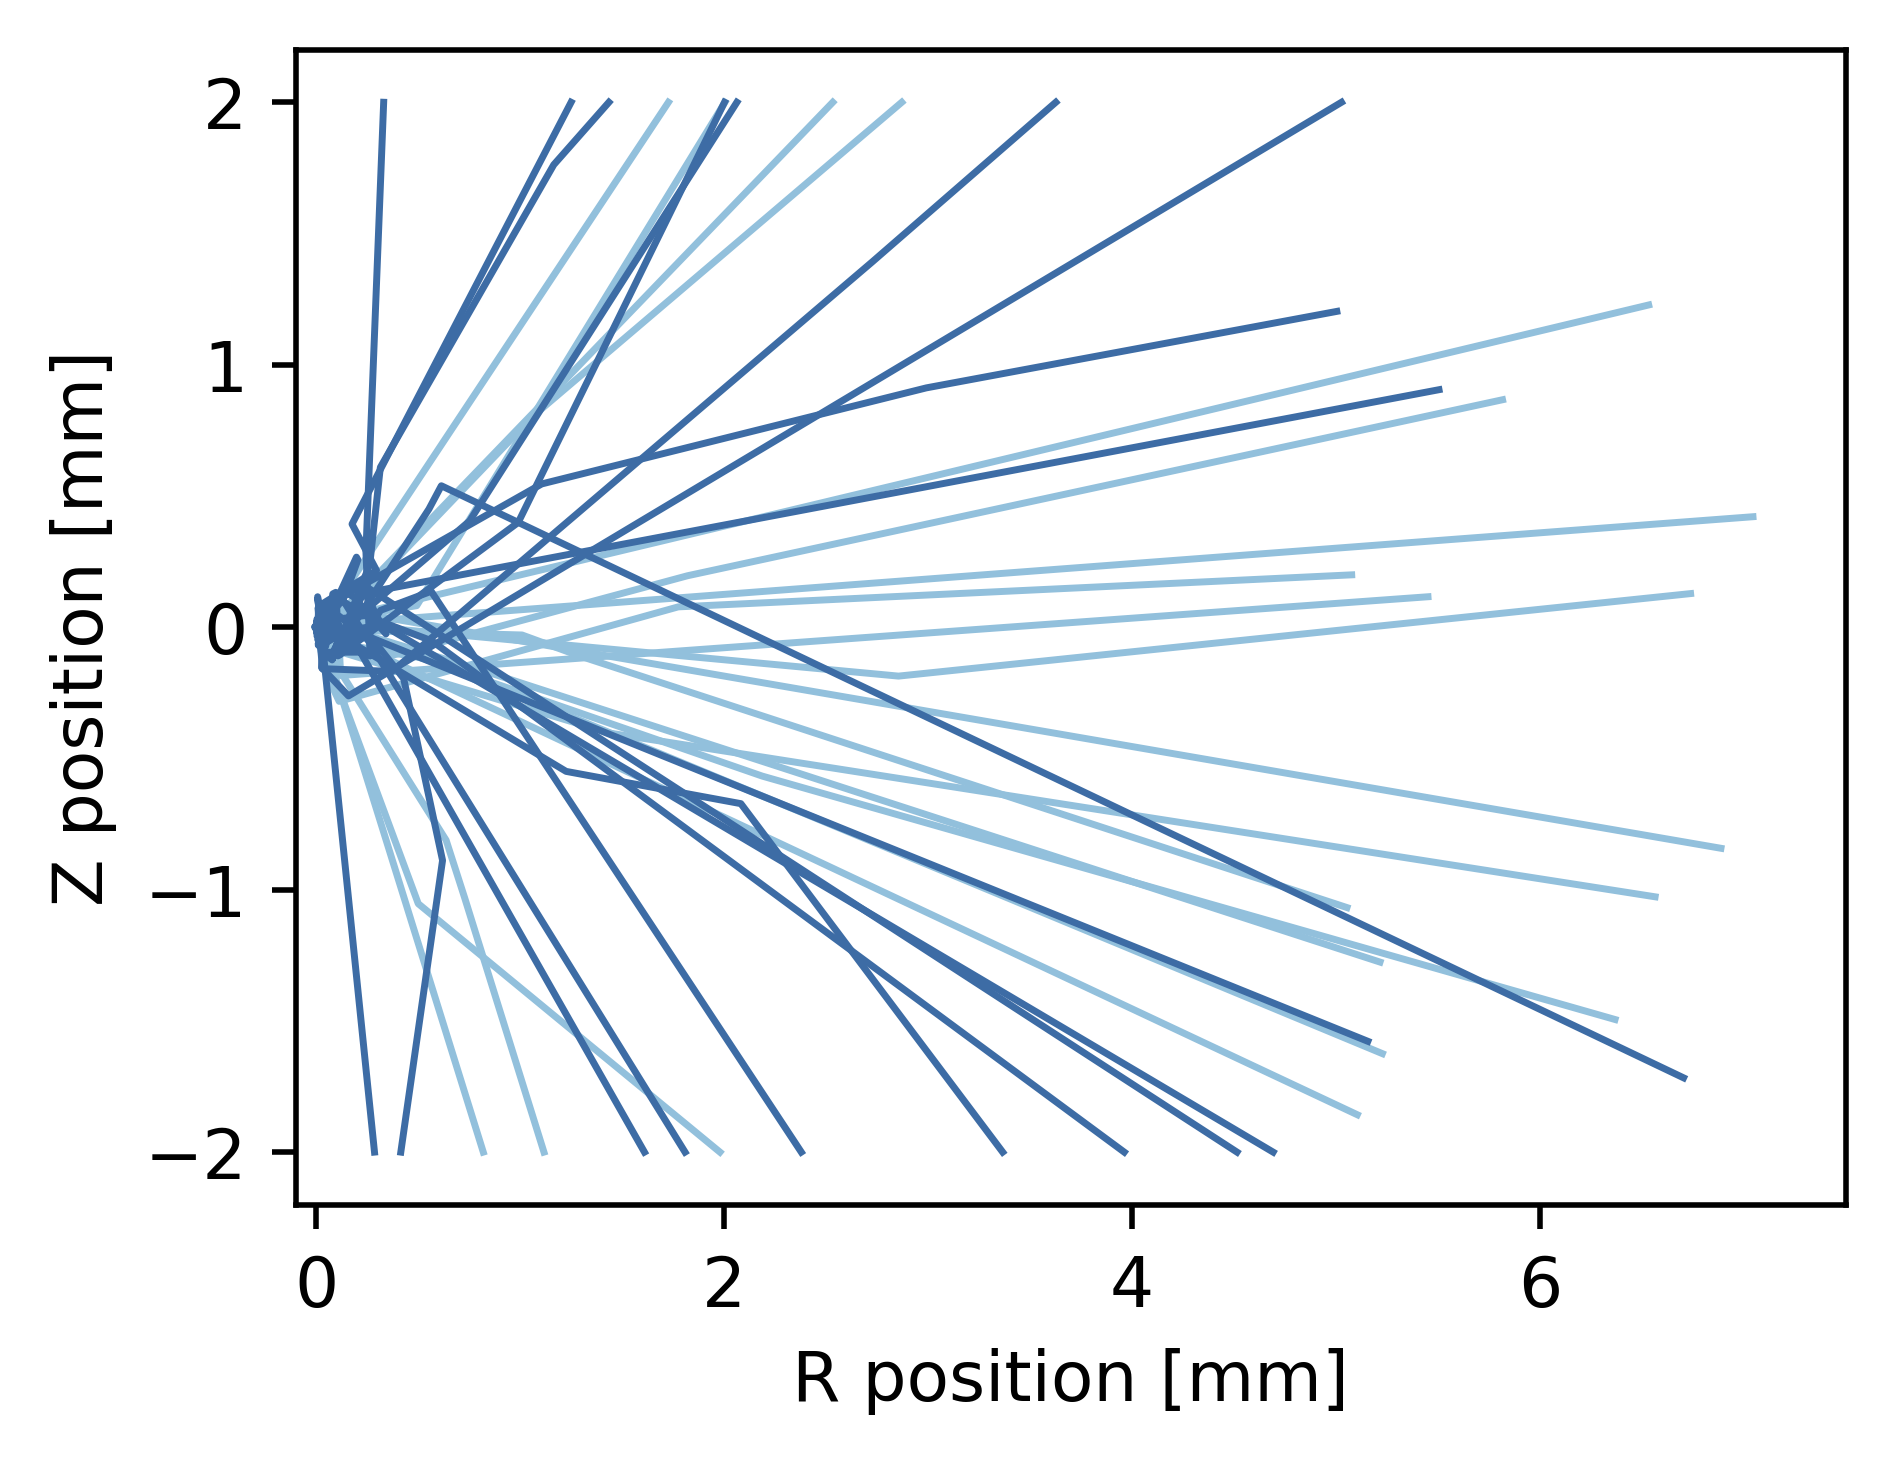

In [19]:
fig = plt.figure(figsize=(4,3), dpi = 500)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        for event in np.unique(data[V][charge]['EventNum'])[:20]:
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e3, data[V][charge]['Y1'][eventCut & chargeCut]*1e3, data[V][charge]['Z1'][eventCut & chargeCut]*1e3
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e3, data[V][charge]['Y3'][eventCut & chargeCut]*1e3, data[V][charge]['Z3'][eventCut & chargeCut]*1e3
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            Tsort, Rsort, Zsort = zip(*sorted(zip(T, R, Z)))

            if event == 0:
                ax.plot(Rsort, Zsort, label = (label[V][charge]), lw = 1, color=colors[V][charge])
            else:
                ax.plot(Rsort, Zsort, lw = 1, color=colors[V][charge])

ax.set_xlabel(r'R position [mm]')
ax.set_ylabel(r'Z position [mm]')
ax.set_xlim(-0.1, 7.5)
ax.set_ylim(-2.2, 2.2)
#ax.legend(loc = 'upper right', fontsize = 8)

(-20.0, 20.0)

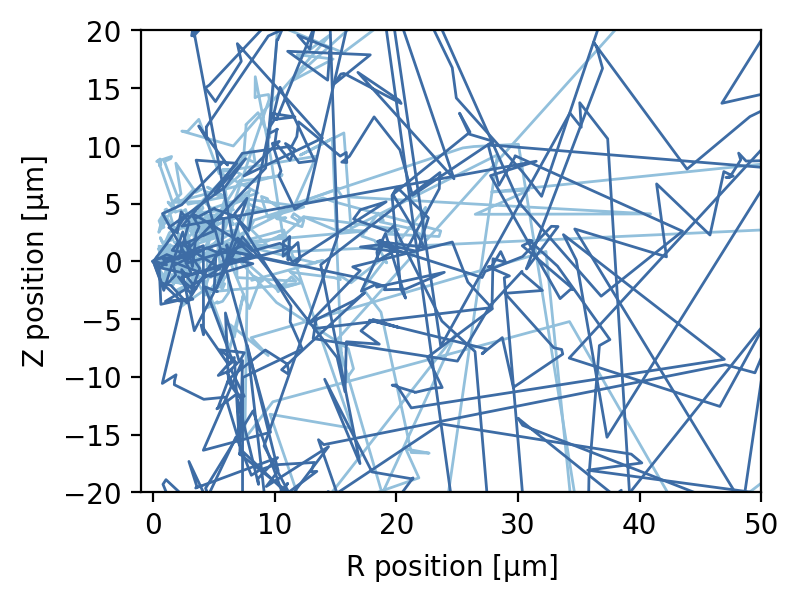

In [14]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        for event in np.unique(data[V][charge]['EventNum'])[:10]:
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e6, data[V][charge]['Y1'][eventCut & chargeCut]*1e6, data[V][charge]['Z1'][eventCut & chargeCut]*1e6
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e6, data[V][charge]['Y3'][eventCut & chargeCut]*1e6, data[V][charge]['Z3'][eventCut & chargeCut]*1e6
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            Tsort, Rsort, Zsort = zip(*sorted(zip(T, R, Z)))

            if event == 0:
                ax.plot(Rsort, Zsort, label = (label[V][charge]), lw = 1, color=colors[V][charge])
            else:
                ax.plot(Rsort, Zsort, lw = 1, color=colors[V][charge])

ax.set_xlabel(r'R position [$\mathrm{\mu m}$]')
ax.set_ylabel(r'Z position [$\mathrm{\mu m}$]')
ax.set_xlim(-1, 50)
ax.set_ylim(-20, 20)
#ax.legend(loc = 'upper right', fontsize = 8)

(-2.0, 2.0)

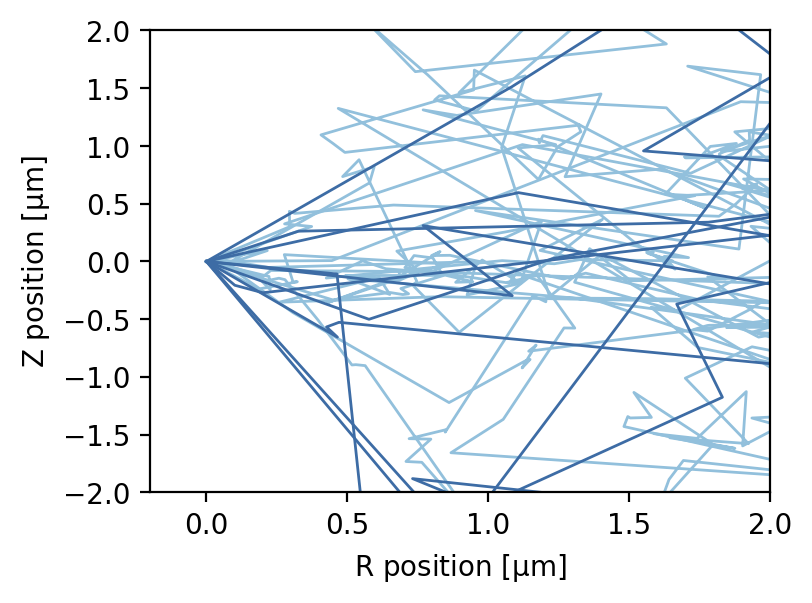

In [15]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        for event in np.unique(data[V][charge]['EventNum'])[:10]:
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e6, data[V][charge]['Y1'][eventCut & chargeCut]*1e6, data[V][charge]['Z1'][eventCut & chargeCut]*1e6
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e6, data[V][charge]['Y3'][eventCut & chargeCut]*1e6, data[V][charge]['Z3'][eventCut & chargeCut]*1e6
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            Tsort, Rsort, Zsort = zip(*sorted(zip(T, R, Z)))

            if event == 0:
                ax.plot(Rsort, Zsort, label = (label[V][charge]), lw = 1, color=colors[V][charge])
            else:
                ax.plot(Rsort, Zsort, lw = 1, color=colors[V][charge])

ax.set_xlabel(r'R position [$\mathrm{\mu m}$]')
ax.set_ylabel(r'Z position [$\mathrm{\mu m}$]')
ax.set_xlim(-0.2, 2)
ax.set_ylim(-2, 2)
#ax.legend(loc = 'upper right', fontsize = 8)

(-2.2, 2.2)

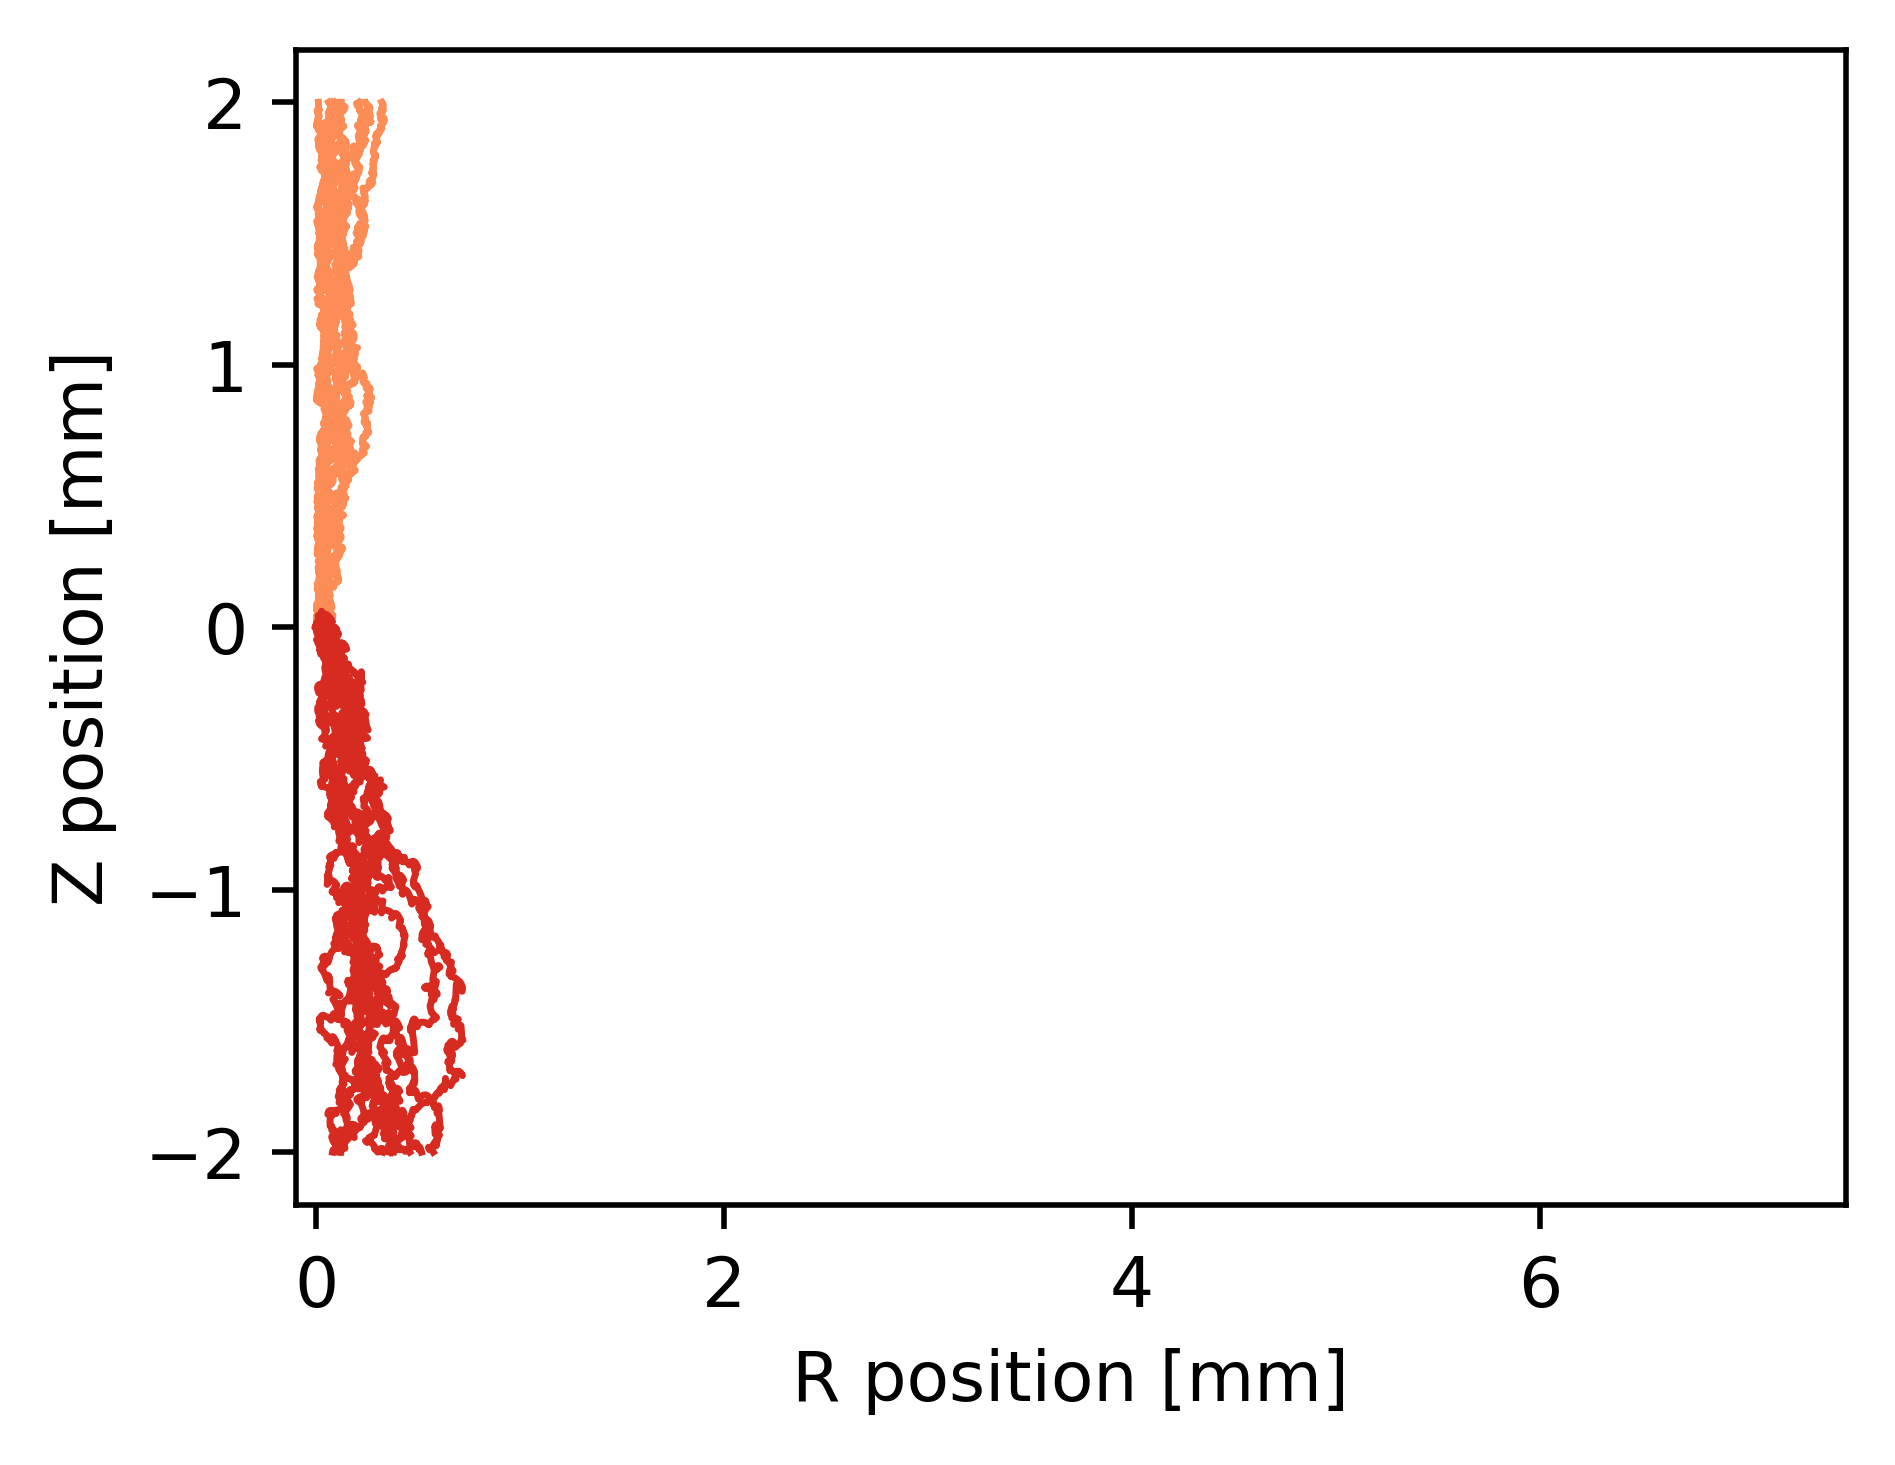

In [20]:
fig = plt.figure(figsize=(4,3), dpi = 500)
ax = plt.subplot(111)

for V in ['4V']:
    for charge in charges:
        for event in np.unique(data[V][charge]['EventNum'])[:10]:
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e3, data[V][charge]['Y1'][eventCut & chargeCut]*1e3, data[V][charge]['Z1'][eventCut & chargeCut]*1e3
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e3, data[V][charge]['Y3'][eventCut & chargeCut]*1e3, data[V][charge]['Z3'][eventCut & chargeCut]*1e3
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            Tsort, Rsort, Zsort = zip(*sorted(zip(T, R, Z)))

            if event == 0:
                ax.plot(Rsort, Zsort, label = (label[V][charge]), lw = 1, color=colors[V][charge])
            else:
                ax.plot(Rsort, Zsort, lw = 1, color=colors[V][charge])

ax.set_xlabel(r'R position [mm]')
ax.set_ylabel(r'Z position [mm]')
ax.set_xlim(-0.1, 7.5)
ax.set_ylim(-2.2, 2.2)
#ax.legend(loc = 'upper right', fontsize = 8)

(-20.0, 20.0)

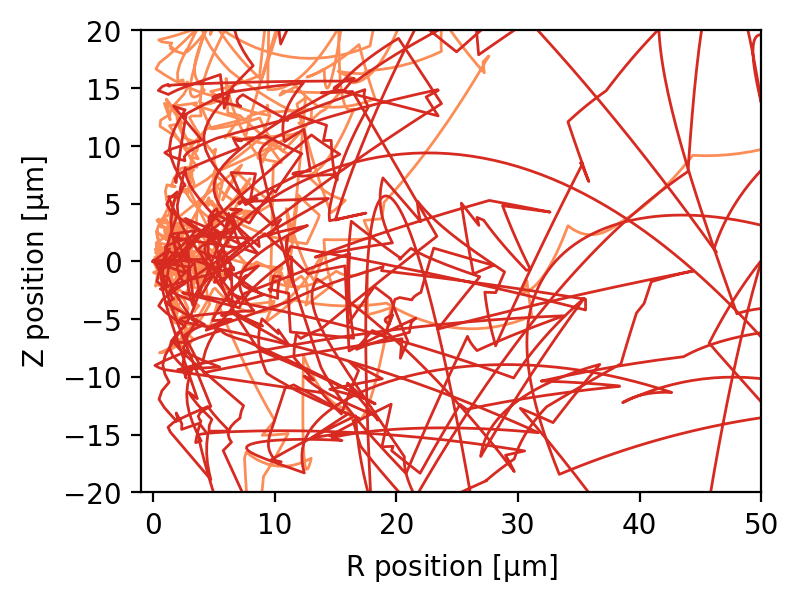

In [17]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['4V']:
    for charge in charges:
        for event in np.unique(data[V][charge]['EventNum'])[:10]:
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e6, data[V][charge]['Y1'][eventCut & chargeCut]*1e6, data[V][charge]['Z1'][eventCut & chargeCut]*1e6
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e6, data[V][charge]['Y3'][eventCut & chargeCut]*1e6, data[V][charge]['Z3'][eventCut & chargeCut]*1e6
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            Tsort, Rsort, Zsort = zip(*sorted(zip(T, R, Z)))

            if event == 0:
                ax.plot(Rsort, Zsort, label = (label[V][charge]), lw = 1, color=colors[V][charge])
            else:
                ax.plot(Rsort, Zsort, lw = 1, color=colors[V][charge])

ax.set_xlabel(r'R position [$\mathrm{\mu m}$]')
ax.set_ylabel(r'Z position [$\mathrm{\mu m}$]')
ax.set_xlim(-1, 50)
ax.set_ylim(-20, 20)
#ax.legend(loc = 'upper right', fontsize = 8)

(-2.0, 2.0)

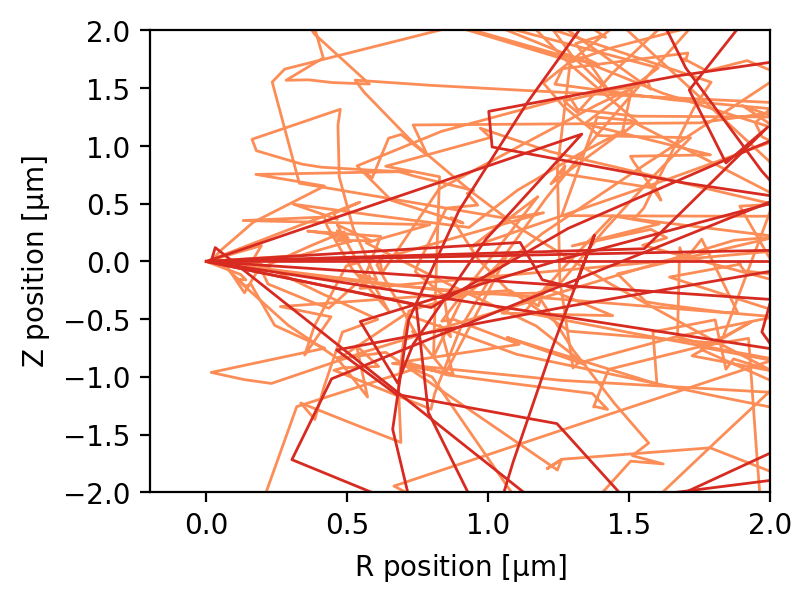

In [18]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['4V']:
    for charge in charges:
        for event in np.unique(data[V][charge]['EventNum'])[:10]:
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e6, data[V][charge]['Y1'][eventCut & chargeCut]*1e6, data[V][charge]['Z1'][eventCut & chargeCut]*1e6
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e6, data[V][charge]['Y3'][eventCut & chargeCut]*1e6, data[V][charge]['Z3'][eventCut & chargeCut]*1e6
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            Tsort, Rsort, Zsort = zip(*sorted(zip(T, R, Z)))

            if event == 0:
                ax.plot(Rsort, Zsort, label = (label[V][charge]), lw = 1, color=colors[V][charge])
            else:
                ax.plot(Rsort, Zsort, lw = 1, color=colors[V][charge])

ax.set_xlabel(r'R position [$\mathrm{\mu m}$]')
ax.set_ylabel(r'Z position [$\mathrm{\mu m}$]')
ax.set_xlim(-0.2, 2)
ax.set_ylim(-2, 2)
#ax.legend(loc = 'upper right', fontsize = 8)

In [19]:
import math

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))

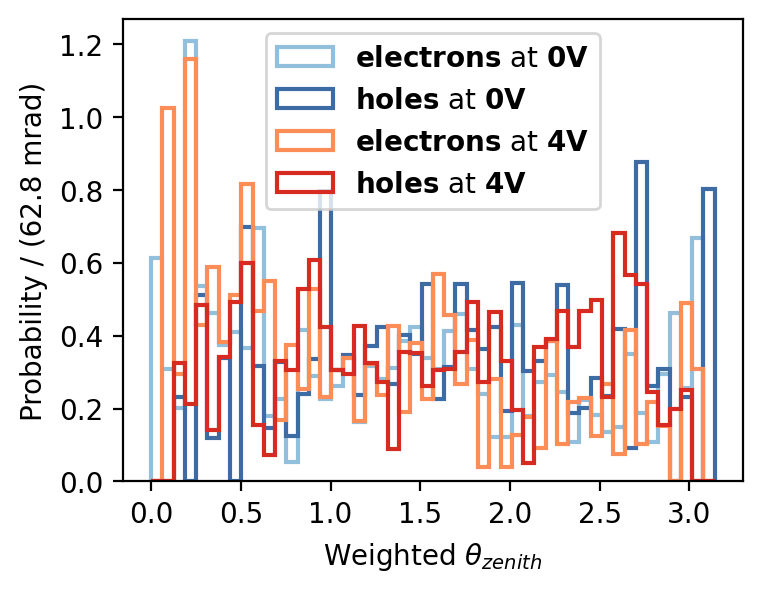

In [20]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)
rholim = 0.01 # imaginary spherical volume where we measure zenith angle

for V in Vs:
    for charge in charges:
        zenith = []
        weights = []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e3, data[V][charge]['Y1'][eventCut & chargeCut]*1e3, data[V][charge]['Z1'][eventCut & chargeCut]*1e3
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e3, data[V][charge]['Y3'][eventCut & chargeCut]*1e3, data[V][charge]['Z3'][eventCut & chargeCut]*1e3
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            rho = np.sqrt(X**2 + Y**2 + Z**2)
            Tsort, Rsort, Zsort, rhosort = zip(*sorted(zip(T, R, Z, rho)))
            
            Zsphere = np.interp([rholim], rhosort, Zsort)[0]
            Rsphere = np.interp([rholim], rhosort, Rsort)[0]

            zenith.append(np.arctan(Rsphere/Zsphere))
            weights.append(1/(2 * np.pi * Rsphere))

        zenith = np.array(zenith)
        weights = np.array(weights)
        zenith = zenith + np.pi * (zenith < 0)
    
        ax.hist(zenith, bins = np.linspace(0, np.pi, 51), label = label[V][charge],
                    histtype='step', color=colors[V][charge], lw = 1.5, weights = weights, density = True)

ax.set_xlabel(r'Weighted $\theta_{zenith}$')
ax.set_ylabel(r'Probability / (62.8 mrad)')
#ax.set_ylim(0, 50)
#ax.set_title(r'Weighted $\theta_{zenith}$ distribution at $\rho =$10 $\mathrm{\mu m}$')
box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc = 'upper center')#, bbox_to_anchor=(1, 0.5))

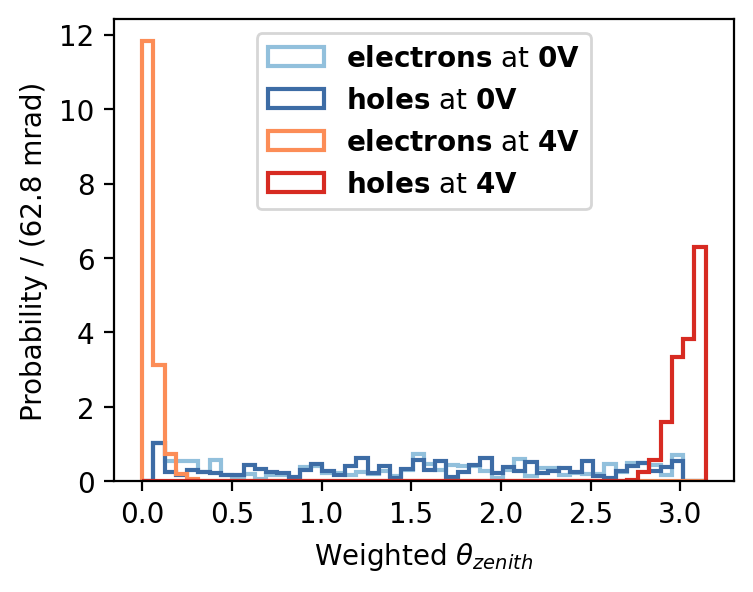

In [21]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)
rholim = 2 # imaginary spherical volume where we measure zenith angle

for V in Vs:
    for charge in charges:
        zenith = []
        weights = []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e3, data[V][charge]['Y1'][eventCut & chargeCut]*1e3, data[V][charge]['Z1'][eventCut & chargeCut]*1e3
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e3, data[V][charge]['Y3'][eventCut & chargeCut]*1e3, data[V][charge]['Z3'][eventCut & chargeCut]*1e3
            Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
            X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
            Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
            Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
            T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
            R = np.sqrt(X**2 + Y**2)
            rho = np.sqrt(X**2 + Y**2 + Z**2)
            Tsort, Rsort, Zsort, rhosort = zip(*sorted(zip(T, R, Z, rho)))
            
            Zsphere = np.interp([rholim], rhosort, Zsort)[0]
            Rsphere = np.interp([rholim], rhosort, Rsort)[0]

            zenith.append(np.arctan(Rsphere/Zsphere))
            weights.append(1/(2 * np.pi * Rsphere))

        zenith = np.array(zenith)
        weights = np.array(weights)
        zenith = zenith + np.pi * (zenith < 0)
    
        ax.hist(zenith, bins = np.linspace(0, np.pi, 51), label = label[V][charge],
                    histtype='step', color=colors[V][charge], lw = 1.5, weights = weights, density = True)

ax.set_xlabel(r'Weighted $\theta_{zenith}$')
ax.set_ylabel(r'Probability / (62.8 mrad)')
#ax.set_ylim(0, 50)
#ax.set_title(r'Weighted $\theta_{zenith}$ distribution at $\rho =$2 $\mathrm{mm}$')
box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc = 'upper center')#, bbox_to_anchor=(1, 0.5))

0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h


Text(0.5, 0, '$\\rho$ [$\\mathrm{mm}$]')

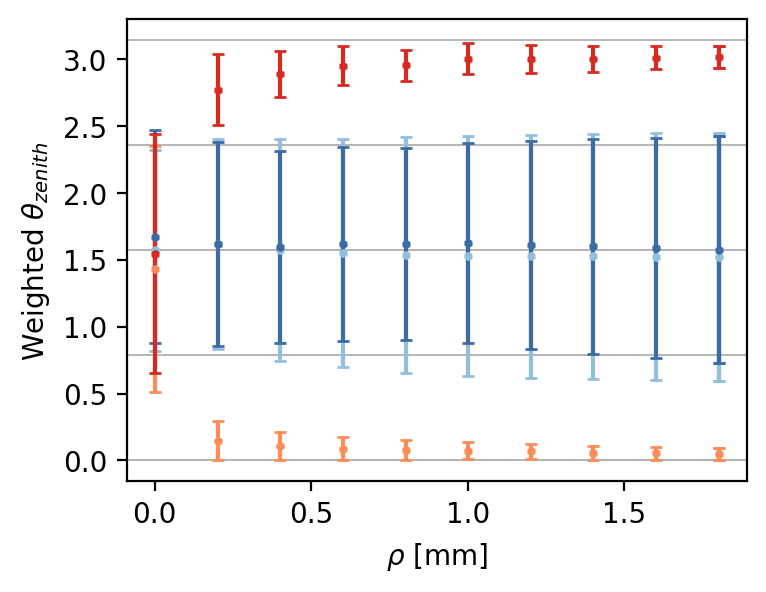

In [22]:
#rholim = np.arange(0.001, 0.3, 0.02) # imaginary spherical volume where we measure zenith angle
rholim = np.arange(0.001, 2, 0.2) # imaginary spherical volume where we measure zenith angle
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for frame in range(len(rholim)):

    for V in Vs:
        print(V)
        for charge in charges:
            print(charge)
            zenith = []
            weights = []
            for event in np.unique(data[V][charge]['EventNum']):
                eventCut = data[V][charge]['EventNum'] == event
                chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
                x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e3, data[V][charge]['Y1'][eventCut & chargeCut]*1e3, data[V][charge]['Z1'][eventCut & chargeCut]*1e3
                x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e3, data[V][charge]['Y3'][eventCut & chargeCut]*1e3, data[V][charge]['Z3'][eventCut & chargeCut]*1e3
                Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
                X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
                Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
                Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
                T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
                R = np.sqrt(X**2 + Y**2)
                rho = np.sqrt(X**2 + Y**2 + Z**2)
                Tsort, Rsort, Zsort, rhosort = zip(*sorted(zip(T, R, Z, rho)))
            
                Zsphere = np.interp([rholim[frame]], rhosort, Zsort)[0]
                Rsphere = np.interp([rholim[frame]], rhosort, Rsort)[0]

                zenith.append(np.arctan(Rsphere/Zsphere))
                weights.append(1/(2 * np.pi * Rsphere))

            zenith = np.array(zenith)
            weights = np.array(weights)
            zenith = zenith + np.pi * (zenith < 0)

            avg, std = weighted_avg_and_std(zenith, weights)

            ax.errorbar([rholim[frame]], avg, yerr = std, ls = "None", color=colors[V][charge], capsize = 2)
            ax.scatter([rholim[frame]], avg, s = 5, marker = "h", zorder=10, color=colors[V][charge])

            if (event == np.unique(data[V][charge]['EventNum'])[-1]) & (rholim[frame] == rholim[-1]):
                ax.errorbar([rholim[frame]], avg, yerr = std, ls = "None", color=colors[V][charge], capsize = 2, label = label[V][charge])

            for line in np.arange(0, np.pi + np.pi / 4, np.pi / 4):
                ax.axhline(line, 0, 1, lw = 0.1, ls = '-', color = 'grey', zorder = -1, alpha = 0.1)
            

ax.set_ylabel(r'Weighted $\theta_{zenith}$')
ax.set_xlabel(r'$\rho$ [$\mathrm{mm}$]')
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h
0V
e
h
4V
e
h


Text(0.5, 0, '$\\rho$ [$\\mathrm{mm}$]')

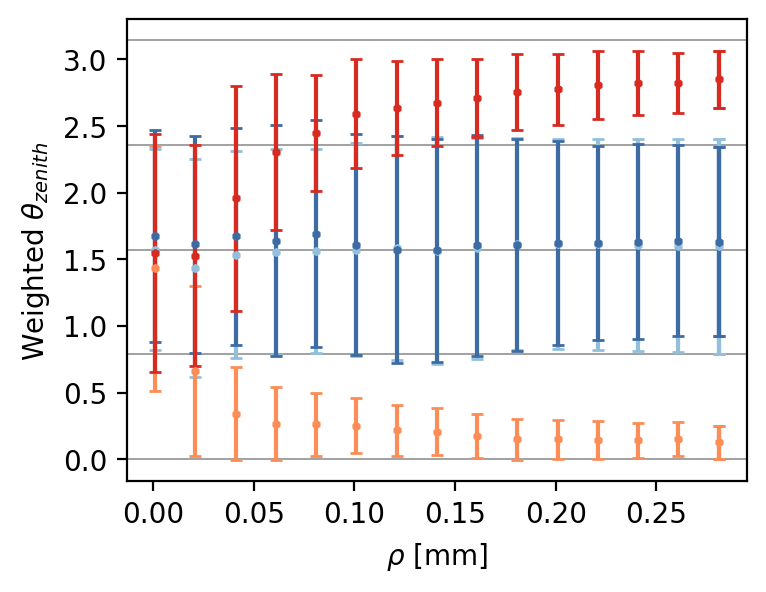

In [23]:
rholim = np.arange(0.001, 0.3, 0.02) # imaginary spherical volume where we measure zenith angle
#rholim = np.arange(0.001, 2, 0.2) # imaginary spherical volume where we measure zenith angle
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for frame in range(len(rholim)):

    for V in Vs:
        print(V)
        for charge in charges:
            print(charge)
            zenith = []
            weights = []
            for event in np.unique(data[V][charge]['EventNum']):
                eventCut = data[V][charge]['EventNum'] == event
                chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
                x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut]*1e3, data[V][charge]['Y1'][eventCut & chargeCut]*1e3, data[V][charge]['Z1'][eventCut & chargeCut]*1e3
                x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut]*1e3, data[V][charge]['Y3'][eventCut & chargeCut]*1e3, data[V][charge]['Z3'][eventCut & chargeCut]*1e3
                Time1, Time3 = data[V][charge]['Time1'][eventCut & chargeCut], data[V][charge]['Time3'][eventCut & chargeCut]
                X = np.concatenate([ [x1[i], x3[i]] for i in range(len(x1))])
                Y = np.concatenate([ [y1[i], y3[i]] for i in range(len(y1))])
                Z = np.concatenate([ [z1[i], z3[i]] for i in range(len(z1))])
                T = np.concatenate([ [Time1[i], Time3[i]] for i in range(len(Time1))])
                R = np.sqrt(X**2 + Y**2)
                rho = np.sqrt(X**2 + Y**2 + Z**2)
                Tsort, Rsort, Zsort, rhosort = zip(*sorted(zip(T, R, Z, rho)))
            
                Zsphere = np.interp([rholim[frame]], rhosort, Zsort)[0]
                Rsphere = np.interp([rholim[frame]], rhosort, Rsort)[0]

                zenith.append(np.arctan(Rsphere/Zsphere))
                weights.append(1/(2 * np.pi * Rsphere))

            zenith = np.array(zenith)
            weights = np.array(weights)
            zenith = zenith + np.pi * (zenith < 0)

            avg, std = weighted_avg_and_std(zenith, weights)

            ax.errorbar([rholim[frame]], avg, yerr = std, ls = "None", color=colors[V][charge], capsize = 2)
            ax.scatter([rholim[frame]], avg, s = 5, marker = "h", zorder=10, color=colors[V][charge])

            if (event == np.unique(data[V][charge]['EventNum'])[-1]) & (rholim[frame] == rholim[-1]):
                ax.errorbar([rholim[frame]], avg, yerr = std, ls = "None", color=colors[V][charge], capsize = 2, label = label[V][charge])

            for line in np.arange(0, np.pi + np.pi / 4, np.pi / 4):
                ax.axhline(line, 0, 1, lw = 0.1, ls = '-', color = 'grey', zorder = -1, alpha = 0.1)
            

ax.set_ylabel(r'Weighted $\theta_{zenith}$')
ax.set_xlabel(r'$\rho$ [$\mathrm{mm}$]')
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

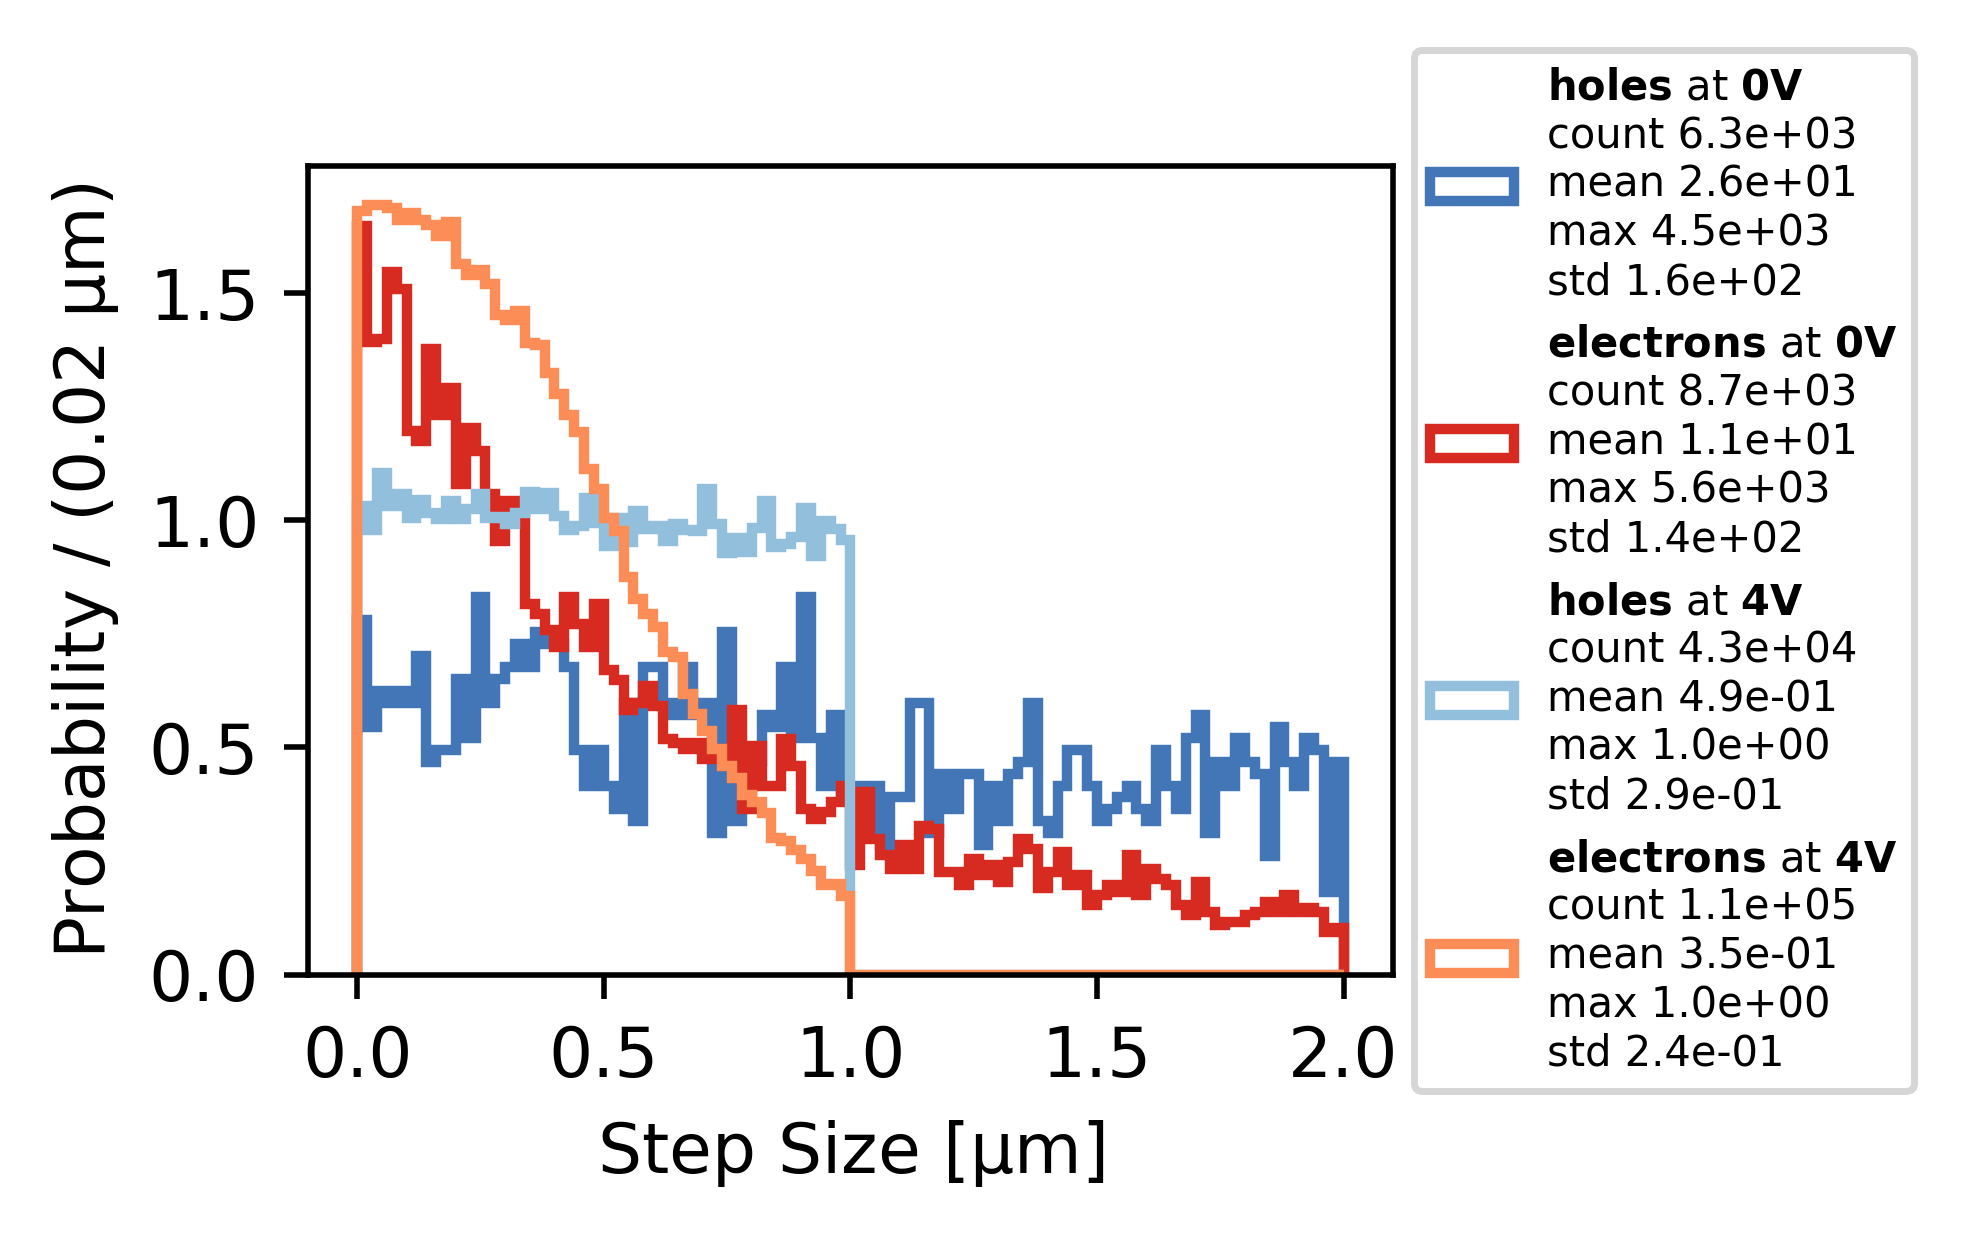

In [30]:
fig = plt.figure(figsize=(5*0.7,3*0.7), dpi = 500)
ax = plt.subplot(111)

for V in Vs:
    for charge in charges:
        stepsize = []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = ((data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)) & (data[V][charge]['Process'] == 'G4CMPLukeScattering')
            stepsize.append( np.sqrt( (data[V][charge]['X3'][eventCut & chargeCut] - data[V][charge]['X1'][eventCut & chargeCut])**2 + 
                                      (data[V][charge]['Y3'][eventCut & chargeCut] - data[V][charge]['Y1'][eventCut & chargeCut])**2 + 
                                      (data[V][charge]['Z3'][eventCut & chargeCut] - data[V][charge]['Z1'][eventCut & chargeCut])**2 ) * 1e6 )

        stepsize = np.concatenate(stepsize)
    
        ax.hist(stepsize, bins = np.linspace(0, 2, 101), 
             label = (label[V][charge] + "\n" + f"count {len(stepsize):.1e}" + "\n" + 
                      f"mean {np.nanmean(stepsize):.1e}" +'\n'+
                      f"max {np.nanmax(stepsize):.1e}" +'\n'+
                      f"std {np.nanstd(stepsize):.1e}"),
                    histtype='step', color=colors[V][charge], lw = 1.5, density = True)

ax.set_xlabel(r'Step Size [$\mathrm{\mu m}$]')
ax.set_ylabel(r'Probability / (0.02 $\mathrm{\mu m}$)')
#ax.set_yscale('log')
#ax.set_xlim(0, 1000)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

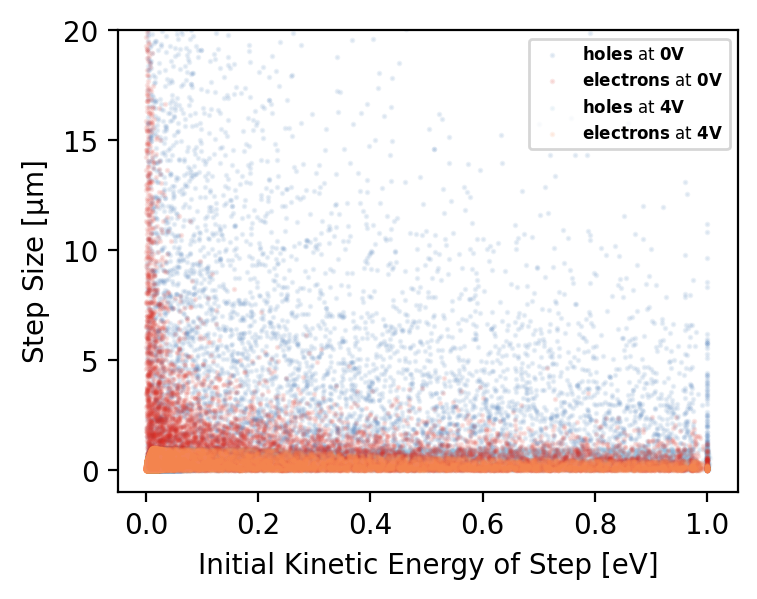

In [23]:
fig = plt.figure(figsize=(4, 3), dpi = 200)
ax = plt.subplot(111)

for V in Vs:
    for charge in charges:
        stepsize, KE = [], []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = ((data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)) & (data[V][charge]['Process'] == 'G4CMPLukeScattering')
            stepsize.append( np.sqrt( (data[V][charge]['X3'][eventCut & chargeCut] - data[V][charge]['X1'][eventCut & chargeCut])**2 + 
                                (data[V][charge]['Y3'][eventCut & chargeCut] - data[V][charge]['Y1'][eventCut & chargeCut])**2 + 
                                (data[V][charge]['Z3'][eventCut & chargeCut] - data[V][charge]['Z1'][eventCut & chargeCut])**2 ) * 1e6 )
            KE.append( data[V][charge]['KE'][eventCut & chargeCut] )

        stepsize = np.concatenate(stepsize)
        KE = np.concatenate(KE)
    
        ax.scatter(KE, stepsize, s = 1, label = (label[V][charge]), color=colors[V][charge], alpha = 0.1, zorder = [0, -1][charge == 'h'])

ax.set_ylabel(r'Step Size [$\mathrm{\mu m}$]')
ax.set_xlabel(r'Initial Kinetic Energy of Step [eV]')
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_ylim(-1, 20)
#ax.set_xlim(None, 1)
box = ax.get_position()
ax.legend(loc='upper right', fontsize=6)

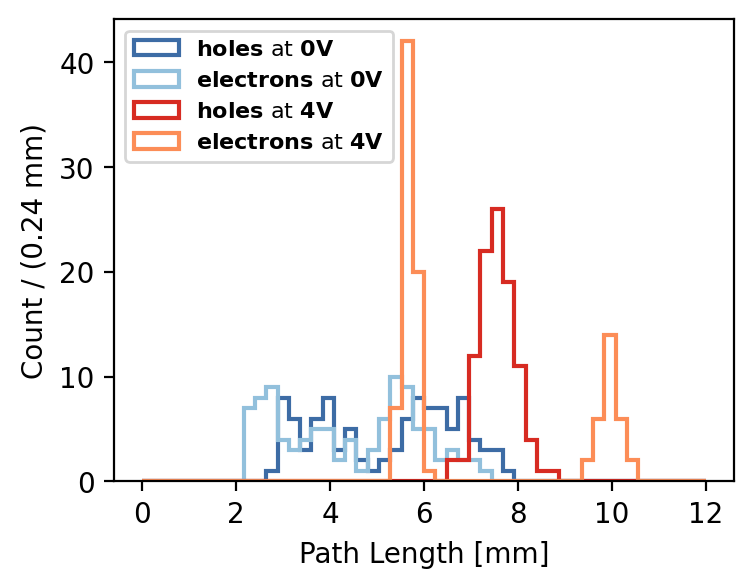

In [28]:
plt.figure(figsize=(4,3), dpi=200)

for V in Vs:
    for charge in charges:
        pathlength = []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut], data[V][charge]['Y1'][eventCut & chargeCut], data[V][charge]['Z1'][eventCut & chargeCut]
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut], data[V][charge]['Y3'][eventCut & chargeCut], data[V][charge]['Z3'][eventCut & chargeCut]
            coord1 = np.array([np.array([x1[i], y1[i], z1[i]]) for i in range(len(x1))])
            coord3 = np.array([np.array([x3[i], y3[i], z3[i]]) for i in range(len(x3))])
            pathlength.append(np.sum(np.sqrt((x3 - x1)**2 + (y3 - y1)**2 + (z3 - z1)**2)))

        plt.hist(np.array(pathlength)*1e3, bins = np.linspace(0, 12, 51), color = colors[V][charge], 
                 label = label[V][charge], 
                 histtype='step', lw=1.5)

plt.xlabel(r'Path Length [mm]')
plt.ylabel(r'Count / (0.24 mm)')
#ax.set_xlim(-1, 7)
#ax.set_ylim(-2.2, 2.2)
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
plt.legend(loc='upper left', fontsize = 8)

Text(0, 0.5, 'Probability / (0.02 mm)')

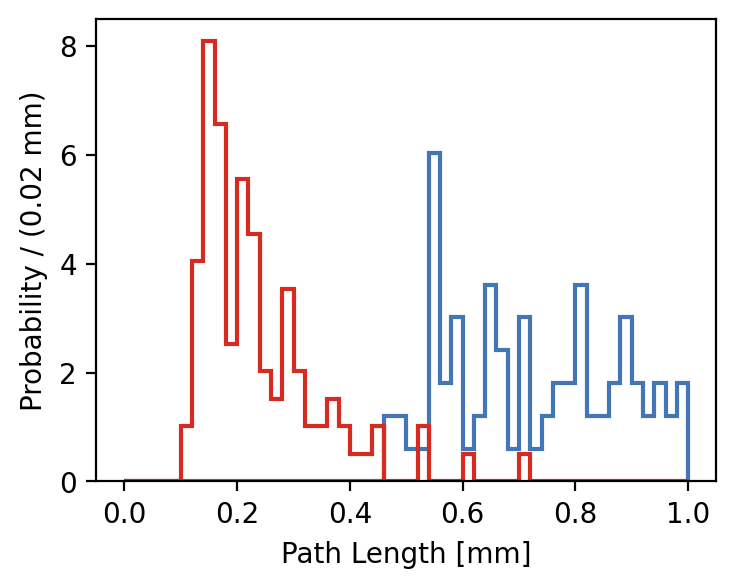

In [33]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        paththresh = []
        for event in np.unique(data[V][charge]['EventNum']):
            #print(event)
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut], data[V][charge]['Y1'][eventCut & chargeCut], data[V][charge]['Z1'][eventCut & chargeCut]
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut], data[V][charge]['Y3'][eventCut & chargeCut], data[V][charge]['Z3'][eventCut & chargeCut]
            coord1 = np.array([np.array([x1[i], y1[i], z1[i]]) for i in range(len(x1))])
            coord3 = np.array([np.array([x3[i], y3[i], z3[i]]) for i in range(len(x3))])
            pathlength = np.array([ np.sum(np.sqrt((x3[:i] - x1[:i])**2 + (y3[:i] - y1[:i])**2 + (z3[:i] - z1[:i])**2)) for i in range(len(x1))])

            WaveVector = scatterData[V][charge]['WaveVector'][scatterData[V][charge]['EventNum'] == event]
            RecoilWaveVector = scatterData[V][charge]['Recoil WaveVector'][scatterData[V][charge]['EventNum'] == event]
            diffWV = abs(WaveVector - ksound[charge])
            diffRWV = abs(RecoilWaveVector - ksound[charge])
            WVmatch = min(min(diffWV), min(diffRWV))
            
            try:
                WVindex = diffWV.tolist().index(WVmatch)
                x_scatter = scatterData[V][charge]['X1'][scatterData[V][charge]['EventNum'] == event][WVindex]
                y_scatter = scatterData[V][charge]['Y1'][scatterData[V][charge]['EventNum'] == event][WVindex]
                z_scatter = scatterData[V][charge]['Z1'][scatterData[V][charge]['EventNum'] == event][WVindex]
                coord_scatter = np.array([x_scatter, y_scatter, z_scatter])
                diff = np.array([ np.sqrt( (coord1[i][0] - coord_scatter[0])**2 + 
                                            (coord1[i][1] - coord_scatter[1])**2 + 
                                            (coord1[i][2] - coord_scatter[2])**2 ) for i in range(len(coord1))])

                posindex = diff.tolist().index(min(diff))
                #print('WaveVector is minimum')
                
            except:
                WVindex = diffRWV.tolist().index(WVmatch)
                x_scatter = scatterData[V][charge]['X3'][scatterData[V][charge]['EventNum'] == event][WVindex]
                y_scatter = scatterData[V][charge]['Y3'][scatterData[V][charge]['EventNum'] == event][WVindex]
                z_scatter = scatterData[V][charge]['Z3'][scatterData[V][charge]['EventNum'] == event][WVindex]
                coord_scatter = np.array([x_scatter, y_scatter, z_scatter])
                diff = np.array([ np.sqrt( (coord3[i][0] - coord_scatter[0])**2 + 
                                            (coord3[i][1] - coord_scatter[1])**2 + 
                                            (coord3[i][2] - coord_scatter[2])**2 ) for i in range(len(coord3))])

                posindex = diff.tolist().index(min(diff))
                #print('Recoil WaveVector is minimum')

            paththresh.append(pathlength[posindex]*1e3)
                
        ax.hist(paththresh, bins=np.linspace(0, 1, 51), color = colors[V][charge], histtype='step', lw = 1.5, density = True,
               label = (label[V][charge] + "\n" + f"count {len(paththresh):.1e}" + "\n" + 
                      f"mean {np.nanmean(np.array(paththresh)*1e3):.1e}" +'\n'+
                      f"std {np.nanstd(np.array(paththresh)*1e3):.1e}") )
        # bins=np.linspace(0, 8, 51)

ax.set_xlabel(r'Path Length [mm]')
ax.set_ylabel(r'Probability / (0.02 mm)')
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)
#ax.legend(loc='upper right', fontsize=8)

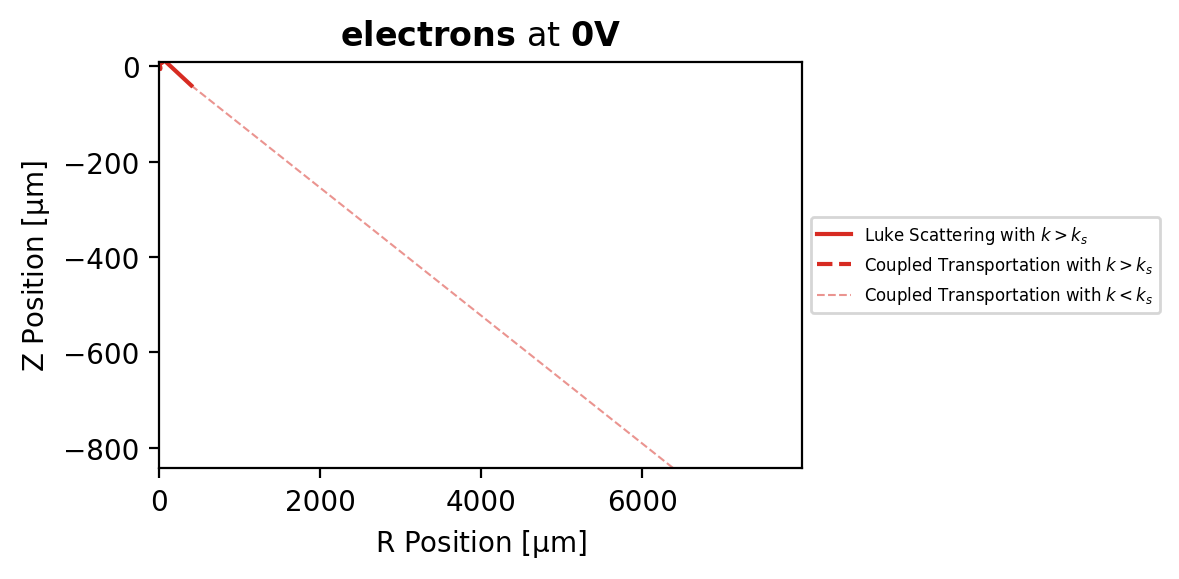

In [17]:
fig = plt.figure(figsize=(6,3), dpi = 200)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in ['e']:
        for event in np.unique(data[V][charge]['EventNum'])[:1]:
            #WViFlag, WVfFlag = True, True
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            for step in range(len(data[V][charge]['X1'][eventCut & chargeCut])):
                
                Process = data[V][charge]['Process'][eventCut & chargeCut][step]
                x1, y1, z1 = (data[V][charge]['X1'][eventCut & chargeCut][step], 
                              data[V][charge]['Y1'][eventCut & chargeCut][step], 
                              data[V][charge]['Z1'][eventCut & chargeCut][step])
                x3, y3, z3 = (data[V][charge]['X3'][eventCut & chargeCut][step], 
                              data[V][charge]['Y3'][eventCut & chargeCut][step], 
                              data[V][charge]['Z3'][eventCut & chargeCut][step])
                r1, r3 = np.sqrt(x1**2 + y1**2), np.sqrt(x3**2 + y3**2)
                
                coord1 = np.array([x1, y1, z1])
                coord3 = np.array([x3, y3, z3])
                dist = np.sqrt(sum(coord3 - coord1)**2)

                x1sc, y1sc, z1sc = (scatterData[V][charge]['X1'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Y1'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Z1'][scatterData[V][charge]['EventNum'] == event])
                x3sc, y3sc, z3sc = (scatterData[V][charge]['X3'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Y3'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Z3'][scatterData[V][charge]['EventNum'] == event])
                coord1sc = np.array([np.array([x1sc[i], y1sc[i], z1sc[i]]) for i in range(len(x1sc))])
                coord3sc = np.array([np.array([x3sc[i], y3sc[i], z3sc[i]]) for i in range(len(x3sc))])

                distsc = np.array([np.sqrt(sum(coord3sc[i] - coord1sc[i])**2) for i in range(len(coord1sc))])

                distdiff = abs(distsc - dist)
                scatterIndex = distdiff.tolist().index(min(distdiff))

                if ((Process == 'G4CMPLukeScattering') | (Process == 'G4CMPTimeStepper')):
                    WaveVector = scatterData[V][charge]['WaveVector'][scatterData[V][charge]['EventNum'] == event][scatterIndex]
                    RecoilWaveVector = scatterData[V][charge]['Recoil WaveVector'][scatterData[V][charge]['EventNum'] == event][scatterIndex]

                    WViFlag = (WaveVector > ksound[charge])
                    WVfFlag = (RecoilWaveVector > ksound[charge])
                
                full = (WViFlag | WVfFlag) & ((Process == 'G4CMPLukeScattering') | (Process == 'G4CMPTimeStepper'))
                end = (WViFlag) & ~(WVfFlag) & ~(Process == 'G4CMPLukeScattering')
                
                if full:
                    ax.plot([r1*1e6, r3*1e6], [z1*1e6, z3*1e6], color = colors[V][charge], ls = lss[Process], lw = 1.5)
                if end:
                    ax.plot([r1*1e6, r3*1e6], [z1*1e6, z3*1e6], color = colors[V][charge], ls = lss[Process], alpha = 0.5, lw = 0.75)
            

                ax.set_xlabel(r'R Position [$\mathrm{\mu m}$]')
                ax.set_ylabel(r'Z Position [$\mathrm{\mu m}$]')
                
                ax.set_xlim(-0.1, np.max([10, r1*1e6*1.25, r3*1e6*1.25]))
                ax.set_ylim(np.min([-10, z1*1e6*1.1, z3*1e6*1]), np.max([10, z1*1e6*1.25, z3*1e6*1]))
                ax.set_title(label[V][charge])
                custom_lines = [Line2D([0], [0], color=colors[V][charge], lw=1.5, ls = lss['G4CMPLukeScattering']),
                                Line2D([0], [0], color=colors[V][charge], lw=1.5, ls = lss['CoupledTransportation']),
                                Line2D([0], [0], color=colors[V][charge], alpha = 0.5, lw = 0.75, ls = lss['CoupledTransportation'])]
                ax.legend(custom_lines, [r'Luke Scattering with $k > k_s$', 
                                         r'Coupled Transportation with $k > k_s$', 
                                         r'Coupled Transportation with $k < k_s$'], loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

                plt.tight_layout()
                #plt.savefig(f'e_0V/{step}.png')

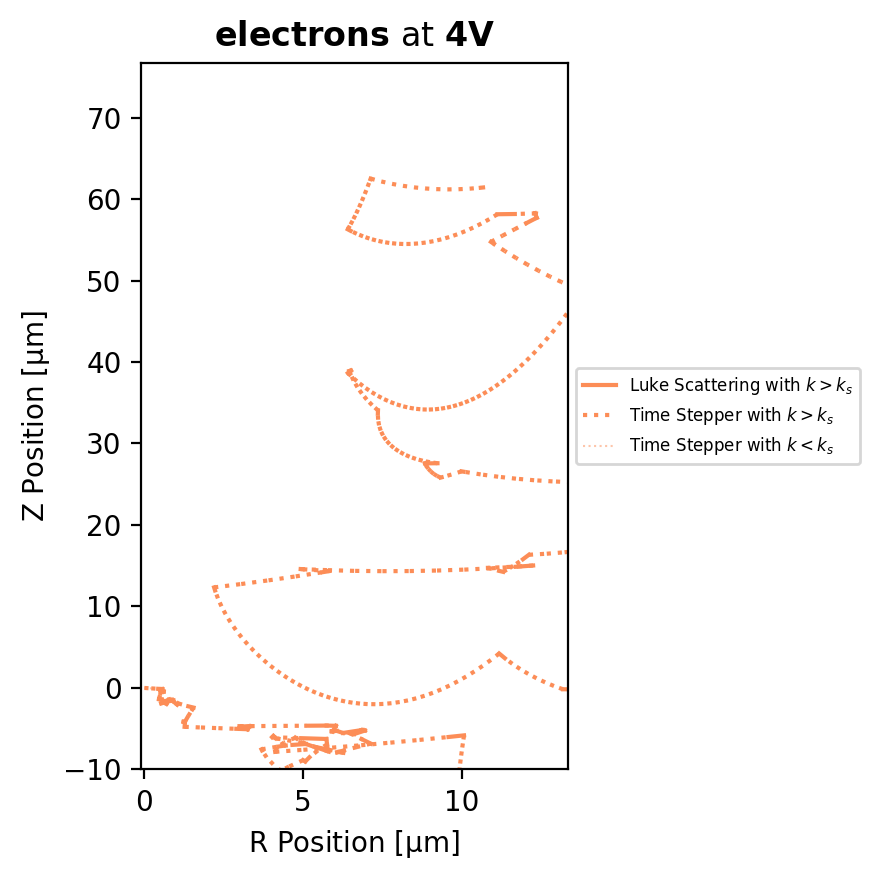

In [18]:
fig = plt.figure(figsize=(6*0.75,6*0.75), dpi = 200)
ax = plt.subplot(111)

for V in ['4V']:
    for charge in ['e']:
        for event in np.unique(data[V][charge]['EventNum'])[:1]:
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            for step in range(len(data[V][charge]['X1'][eventCut & chargeCut]))[:500]:
                
                Process = data[V][charge]['Process'][eventCut & chargeCut][step]
                x1, y1, z1 = (data[V][charge]['X1'][eventCut & chargeCut][step], 
                              data[V][charge]['Y1'][eventCut & chargeCut][step], 
                              data[V][charge]['Z1'][eventCut & chargeCut][step])
                x3, y3, z3 = (data[V][charge]['X3'][eventCut & chargeCut][step], 
                              data[V][charge]['Y3'][eventCut & chargeCut][step], 
                              data[V][charge]['Z3'][eventCut & chargeCut][step])
                r1, r3 = np.sqrt(x1**2 + y1**2), np.sqrt(x3**2 + y3**2)
                
                coord1 = np.array([x1, y1, z1])
                coord3 = np.array([x3, y3, z3])
                dist = np.sqrt(sum(coord3 - coord1)**2)

                x1sc, y1sc, z1sc = (scatterData[V][charge]['X1'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Y1'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Z1'][scatterData[V][charge]['EventNum'] == event])
                x3sc, y3sc, z3sc = (scatterData[V][charge]['X3'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Y3'][scatterData[V][charge]['EventNum'] == event], 
                                    scatterData[V][charge]['Z3'][scatterData[V][charge]['EventNum'] == event])
                coord1sc = np.array([np.array([x1sc[i], y1sc[i], z1sc[i]]) for i in range(len(x1sc))])
                coord3sc = np.array([np.array([x3sc[i], y3sc[i], z3sc[i]]) for i in range(len(x3sc))])

                distsc = np.array([np.sqrt(sum(coord3sc[i] - coord1sc[i])**2) for i in range(len(coord1sc))])

                distdiff = abs(distsc - dist)
                scatterIndex = distdiff.tolist().index(min(distdiff))

                #print(Process)
                if Process == 'G4CMPLukeScattering':
                    WaveVector = scatterData[V][charge]['WaveVector'][scatterData[V][charge]['EventNum'] == event][scatterIndex]
                    #print(WaveVector)
                    RecoilWaveVector = scatterData[V][charge]['Recoil WaveVector'][scatterData[V][charge]['EventNum'] == event][scatterIndex]
                    #print(RecoilWaveVector)
                    #print(ksound[charge])

                    WViFlag = (WaveVector > ksound[charge])
                    WVfFlag = (RecoilWaveVector > ksound[charge])
                
                full = (WViFlag | WVfFlag) & ((Process == 'G4CMPLukeScattering') | (Process == 'G4CMPTimeStepper'))
                end = (WViFlag) & ~(WVfFlag) & ~(Process == 'G4CMPLukeScattering')
                
                if full:
                    #print('plotting')
                    #print()
                    ax.plot([r1*1e6, r3*1e6], [z1*1e6, z3*1e6], color = colors[V][charge], ls = lss[Process], lw = 1.5)
                if end:
                    #print('plotting')
                    #print()
                    ax.plot([r1*1e6, r3*1e6], [z1*1e6, z3*1e6], color = colors[V][charge], ls = lss[Process], alpha = 0.5, lw = 0.75)
            

                ax.set_xlabel(r'R Position [$\mathrm{\mu m}$]')
                ax.set_ylabel(r'Z Position [$\mathrm{\mu m}$]')
                ax.set_xlim(-0.1, np.max([10, r1*1e6*1.25, r3*1e6*1.25]))
                ax.set_ylim(np.min([-10, z1*1e6*1.1, z3*1e6*1]), np.max([10, z1*1e6*1.25, z3*1e6*1]))
                #ax.set_ylim(np.min([-50, -abs(z1*1e6*1.1), -abs(z3*1e6*1)]), np.max([50, z1*1e6*1.25, z3*1e6*1]))
                ax.set_title(label[V][charge])
                custom_lines = [Line2D([0], [0], color=colors[V][charge], lw=1.5, ls = lss['G4CMPLukeScattering']),
                                Line2D([0], [0], color=colors[V][charge], lw=1.5, ls = lss['G4CMPTimeStepper']),
                                Line2D([0], [0], color=colors[V][charge], alpha = 0.5, lw = 0.75, ls = lss['G4CMPTimeStepper'])]
                ax.legend(custom_lines, [r'Luke Scattering with $k > k_s$', 
                                         r'Time Stepper with $k > k_s$', 
                                         r'Time Stepper with $k < k_s$'], loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)

                plt.tight_layout()
                #plt.savefig(f'e_4V/{step}.png')

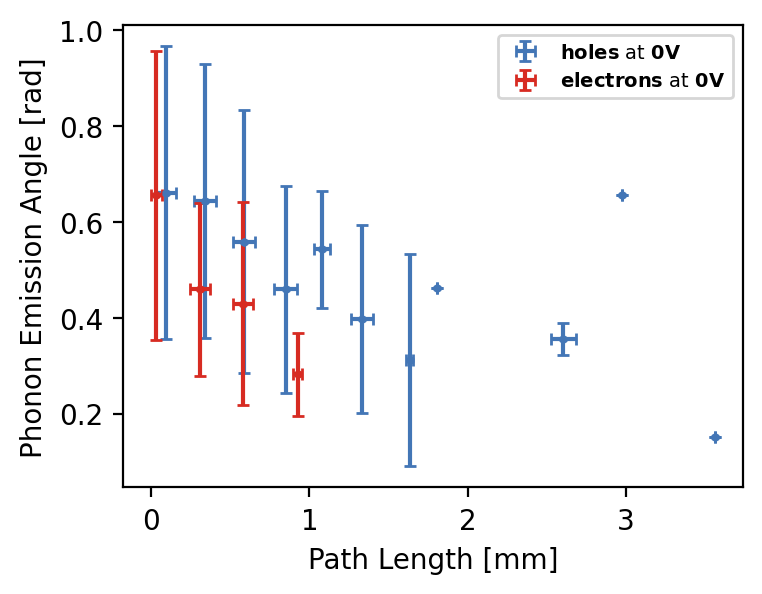

In [14]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        pathLengths = []
        phononThetas = []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut], data[V][charge]['Y1'][eventCut & chargeCut], data[V][charge]['Z1'][eventCut & chargeCut]
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut], data[V][charge]['Y3'][eventCut & chargeCut], data[V][charge]['Z3'][eventCut & chargeCut]
            coord1 = np.array([np.array([x1[i], y1[i], z1[i]]) for i in range(len(x1))])
            coord3 = np.array([np.array([x3[i], y3[i], z3[i]]) for i in range(len(x3))])
            pathlength = np.array([ np.sum(np.sqrt((x3[:i] - x1[:i])**2 + (y3[:i] - y1[:i])**2 + (z3[:i] - z1[:i])**2)) for i in range(len(x1))])

            for entry in range(len(scatterData[V][charge]['Phonon Theta'][scatterData[V][charge]['EventNum'] == event])):
                x1_scatter = scatterData[V][charge]['X1'][scatterData[V][charge]['EventNum'] == event][entry]
                y1_scatter = scatterData[V][charge]['Y1'][scatterData[V][charge]['EventNum'] == event][entry]
                z1_scatter = scatterData[V][charge]['Z1'][scatterData[V][charge]['EventNum'] == event][entry]
                x3_scatter = scatterData[V][charge]['X3'][scatterData[V][charge]['EventNum'] == event][entry]
                y3_scatter = scatterData[V][charge]['Y3'][scatterData[V][charge]['EventNum'] == event][entry]
                z3_scatter = scatterData[V][charge]['Z3'][scatterData[V][charge]['EventNum'] == event][entry]
                coord1_scatter = np.array([x1_scatter, y1_scatter, z1_scatter])
                coord3_scatter = np.array([x3_scatter, y3_scatter, z3_scatter])

                diff1 = np.array([ np.sqrt( (coord1[i][0] - coord1_scatter[0])**2 + 
                                            (coord1[i][1] - coord1_scatter[1])**2 + 
                                            (coord1[i][2] - coord1_scatter[2])**2 ) for i in range(len(coord1))])
                diff3 = np.array([ np.sqrt( (coord3[i][0] - coord3_scatter[0])**2 + 
                                            (coord3[i][1] - coord3_scatter[1])**2 + 
                                            (coord3[i][2] - coord3_scatter[2])**2 ) for i in range(len(coord3))])

                index1 = diff1.tolist().index(min(diff1))
                index3 = diff3.tolist().index(min(diff3))
                pathLengths.append(pathlength[index1]*1e3)
                phononThetas.append(scatterData[V][charge]['Phonon Theta'][scatterData[V][charge]['EventNum'] == event][entry])

        path_bins = np.arange(0, 4 + 0.25, 0.25)
        pathLengths = np.array(pathLengths)
        phononThetas = np.array(phononThetas)
        path_mean, path_std = [], []
        theta_mean, theta_std = [], []
        for step in range(len(path_bins)):
            path_cut = (pathLengths > path_bins[step - 1]) & (pathLengths < path_bins[step])
            path_mean.append(np.mean(pathLengths[path_cut]))
            path_std.append(np.std(pathLengths[path_cut]))
            theta_mean.append(np.mean(phononThetas[path_cut]))
            theta_std.append(np.std(phononThetas[path_cut]))

        ax.errorbar(path_mean, theta_mean, xerr = path_std, yerr = theta_std, ls = "None", 
            color=colors[V][charge], capsize = 2, label = label[V][charge])
        ax.scatter(path_mean, theta_mean, s = 5, marker = "h", color = colors[V][charge], zorder=10)

ax.set_xlabel(r'Path Length [mm]')
ax.set_ylabel(r'Phonon Emission Angle [rad]')
#custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['0V']['h'], markersize=5),
#                Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['0V']['e'], markersize=5)]
ax.legend(loc='upper right', fontsize = 7)

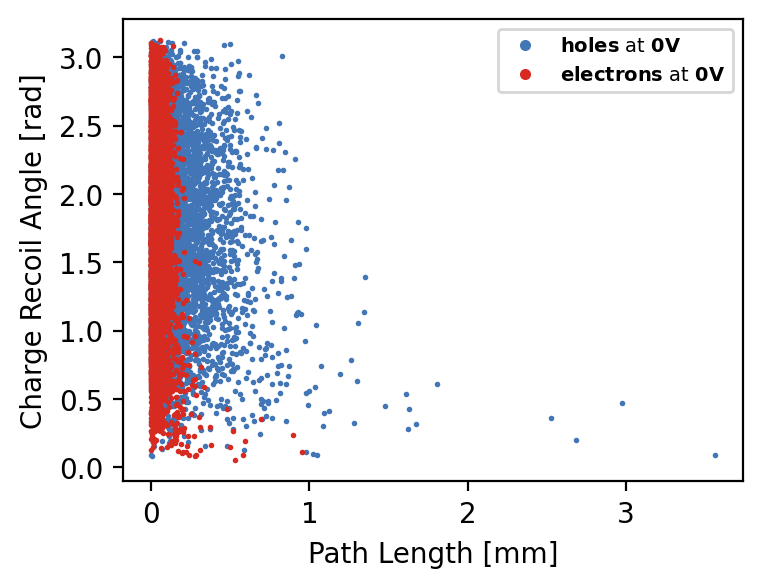

In [69]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut], data[V][charge]['Y1'][eventCut & chargeCut], data[V][charge]['Z1'][eventCut & chargeCut]
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut], data[V][charge]['Y3'][eventCut & chargeCut], data[V][charge]['Z3'][eventCut & chargeCut]
            coord1 = np.array([np.array([x1[i], y1[i], z1[i]]) for i in range(len(x1))])
            coord3 = np.array([np.array([x3[i], y3[i], z3[i]]) for i in range(len(x3))])
            pathlength = np.array([ np.sum(np.sqrt((x3[:i] - x1[:i])**2 + (y3[:i] - y1[:i])**2 + (z3[:i] - z1[:i])**2)) for i in range(len(x1))])

            for entry in range(len(scatterData[V][charge]['Phonon Theta'][scatterData[V][charge]['EventNum'] == event])):
                x1_scatter = scatterData[V][charge]['X1'][scatterData[V][charge]['EventNum'] == event][entry]
                y1_scatter = scatterData[V][charge]['Y1'][scatterData[V][charge]['EventNum'] == event][entry]
                z1_scatter = scatterData[V][charge]['Z1'][scatterData[V][charge]['EventNum'] == event][entry]
                x3_scatter = scatterData[V][charge]['X3'][scatterData[V][charge]['EventNum'] == event][entry]
                y3_scatter = scatterData[V][charge]['Y3'][scatterData[V][charge]['EventNum'] == event][entry]
                z3_scatter = scatterData[V][charge]['Z3'][scatterData[V][charge]['EventNum'] == event][entry]
                coord1_scatter = np.array([x1_scatter, y1_scatter, z1_scatter])
                coord3_scatter = np.array([x3_scatter, y3_scatter, z3_scatter])

                diff1 = np.array([ np.sqrt( (coord1[i][0] - coord1_scatter[0])**2 + 
                                            (coord1[i][1] - coord1_scatter[1])**2 + 
                                            (coord1[i][2] - coord1_scatter[2])**2 ) for i in range(len(coord1))])
                diff3 = np.array([ np.sqrt( (coord3[i][0] - coord3_scatter[0])**2 + 
                                            (coord3[i][1] - coord3_scatter[1])**2 + 
                                            (coord3[i][2] - coord3_scatter[2])**2 ) for i in range(len(coord3))])

                index1 = diff1.tolist().index(min(diff1))
                index3 = diff3.tolist().index(min(diff3))
                if index1 == index3:
                    plt.scatter(pathlength[index1]*1e3, 
                                scatterData[V][charge]['Recoil Theta'][scatterData[V][charge]['EventNum'] == event][entry], 
                                s = 1, color = colors[V][charge])
                else:
                    print("Indices don't match!")

ax.set_xlabel(r'Path Length [mm]')
ax.set_ylabel(r'Charge Recoil Angle [rad]')
custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['0V']['h'], markersize=5),
                Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['0V']['e'], markersize=5)]
ax.legend(custom_lines, [label['0V']['h'], label['0V']['e']], loc='upper right', fontsize = 7)

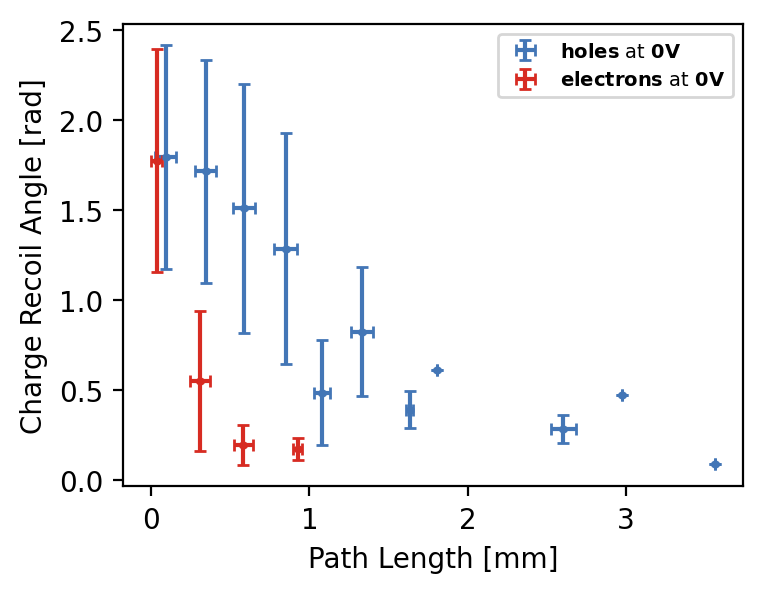

In [15]:
fig = plt.figure(figsize=(4,3), dpi = 200)
ax = plt.subplot(111)

for V in ['0V']:
    for charge in charges:
        pathLengths = []
        phononThetas = []
        for event in np.unique(data[V][charge]['EventNum']):
            eventCut = data[V][charge]['EventNum'] == event
            chargeCut = (data[V][charge]['Charge'] == -1) | (data[V][charge]['Charge'] == 1)
            x1, y1, z1 = data[V][charge]['X1'][eventCut & chargeCut], data[V][charge]['Y1'][eventCut & chargeCut], data[V][charge]['Z1'][eventCut & chargeCut]
            x3, y3, z3 = data[V][charge]['X3'][eventCut & chargeCut], data[V][charge]['Y3'][eventCut & chargeCut], data[V][charge]['Z3'][eventCut & chargeCut]
            coord1 = np.array([np.array([x1[i], y1[i], z1[i]]) for i in range(len(x1))])
            coord3 = np.array([np.array([x3[i], y3[i], z3[i]]) for i in range(len(x3))])
            pathlength = np.array([ np.sum(np.sqrt((x3[:i] - x1[:i])**2 + (y3[:i] - y1[:i])**2 + (z3[:i] - z1[:i])**2)) for i in range(len(x1))])

            for entry in range(len(scatterData[V][charge]['Phonon Theta'][scatterData[V][charge]['EventNum'] == event])):
                x1_scatter = scatterData[V][charge]['X1'][scatterData[V][charge]['EventNum'] == event][entry]
                y1_scatter = scatterData[V][charge]['Y1'][scatterData[V][charge]['EventNum'] == event][entry]
                z1_scatter = scatterData[V][charge]['Z1'][scatterData[V][charge]['EventNum'] == event][entry]
                x3_scatter = scatterData[V][charge]['X3'][scatterData[V][charge]['EventNum'] == event][entry]
                y3_scatter = scatterData[V][charge]['Y3'][scatterData[V][charge]['EventNum'] == event][entry]
                z3_scatter = scatterData[V][charge]['Z3'][scatterData[V][charge]['EventNum'] == event][entry]
                coord1_scatter = np.array([x1_scatter, y1_scatter, z1_scatter])
                coord3_scatter = np.array([x3_scatter, y3_scatter, z3_scatter])

                diff1 = np.array([ np.sqrt( (coord1[i][0] - coord1_scatter[0])**2 + 
                                            (coord1[i][1] - coord1_scatter[1])**2 + 
                                            (coord1[i][2] - coord1_scatter[2])**2 ) for i in range(len(coord1))])
                diff3 = np.array([ np.sqrt( (coord3[i][0] - coord3_scatter[0])**2 + 
                                            (coord3[i][1] - coord3_scatter[1])**2 + 
                                            (coord3[i][2] - coord3_scatter[2])**2 ) for i in range(len(coord3))])

                index1 = diff1.tolist().index(min(diff1))
                index3 = diff3.tolist().index(min(diff3))
                pathLengths.append(pathlength[index1]*1e3)
                phononThetas.append(scatterData[V][charge]['Recoil Theta'][scatterData[V][charge]['EventNum'] == event][entry])

        path_bins = np.arange(0, 4 + 0.25, 0.25)
        pathLengths = np.array(pathLengths)
        phononThetas = np.array(phononThetas)
        path_mean, path_std = [], []
        theta_mean, theta_std = [], []
        for step in range(len(path_bins)):
            path_cut = (pathLengths > path_bins[step - 1]) & (pathLengths < path_bins[step])
            path_mean.append(np.mean(pathLengths[path_cut]))
            path_std.append(np.std(pathLengths[path_cut]))
            theta_mean.append(np.mean(phononThetas[path_cut]))
            theta_std.append(np.std(phononThetas[path_cut]))

        ax.errorbar(path_mean, theta_mean, xerr = path_std, yerr = theta_std, ls = "None", 
            color=colors[V][charge], capsize = 2, label = label[V][charge])
        ax.scatter(path_mean, theta_mean, s = 5, marker = "h", color = colors[V][charge], zorder=10)

ax.set_xlabel(r'Path Length [mm]')
ax.set_ylabel(r'Charge Recoil Angle [rad]')
#custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['0V']['h'], markersize=5),
#                Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['0V']['e'], markersize=5)]
ax.legend(loc='upper right', fontsize = 7)

# Backups